In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, confusion_matrix, f1_score,
                             mean_absolute_error, mean_squared_error, r2_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

sns.set_theme(style="darkgrid", palette="deep")

# Дрібна світла сітка, щоб легше зчитувати значення з графіків
plt.rcParams.update({
    "axes.grid": True,
    "axes.grid.which": "both",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "grid.alpha": 0.35,
    "grid.linewidth": 0.6,
})

In [2]:
# Крок 1. Первинний аналіз даних
# Файл без заголовків, тож задаємо назви колонок самі (з опису abalone.names)
cols = ["sex", "length", "diameter", "height", "whole_weight",
        "shucked_weight", "viscera_weight", "shell_weight", "rings"]
df = pd.read_csv("abalone.data", header=None, names=cols)
df.shape

(4177, 9)

In [3]:
df.head()

,sex,length,diameter,height,whole_weight,shucked_weight,viscera_weight,shell_weight,rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4177 entries, 0 to 4176
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sex             4177 non-null   object 
 1   length          4177 non-null   float64
 2   diameter        4177 non-null   float64
 3   height          4177 non-null   float64
 4   whole_weight    4177 non-null   float64
 5   shucked_weight  4177 non-null   float64
 6   viscera_weight  4177 non-null   float64
 7   shell_weight    4177 non-null   float64
 8   rings           4177 non-null   int64  
dtypes: float64(7), int64(1), object(1)
memory usage: 293.8+ KB


In [5]:
# Перевірка пропусків
df.isna().sum()

sex               0
length            0
diameter          0
height            0
whole_weight      0
shucked_weight    0
viscera_weight    0
shell_weight      0
rings             0
dtype: int64

In [6]:
# Пропусків немає взагалі - дуже чисті дані. 7 фіч - це числові виміри (розміри в мм і ваги в грамах), sex - текстова категорія (M/F/I), а rings - ціле число (наш таргет для регресії).

count    4177.000000
mean        9.933684
std         3.224169
min         1.000000
25%         8.000000
50%         9.000000
75%        11.000000
max        29.000000
Name: rings, dtype: float64


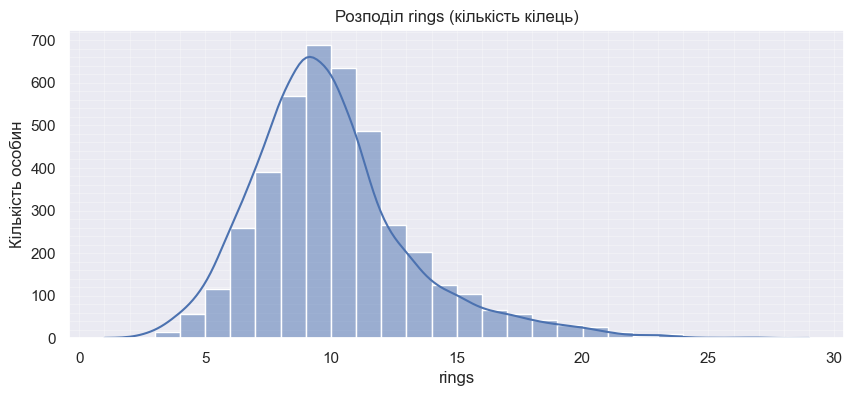

In [7]:
# Розподіл таргета rings (кількість кілець ~ вік)
print(df["rings"].describe())

plt.figure(figsize=(10, 4))
sns.histplot(df["rings"], bins=range(1, 30), kde=True)
plt.title("Розподіл rings (кількість кілець)")
plt.xlabel("rings")
plt.ylabel("Кількість особин")
plt.show()

In [8]:
# rings - від 1 до 29, але майже всі мушлі мають 7-12 кілець; розподіл трохи витягнутий вправо (дуже старих особин мало). За описом датасету вік ~ rings + 1.5 року. Для регресії ми прогнозуємо саме rings.

In [9]:
# Баланс класів sex
df["sex"].value_counts()

sex
M    1528
I    1342
F    1307
Name: count, dtype: int64

In [10]:
# Три статі приблизно порівну (M ~1528, I ~1342, F ~1307), де I = infant (молодь), M/F - дорослі самці/самки. Важливо: у основній задачі (регресія віку) sex - це вхідна фіча (закодуємо її в числа), а в додатковій задачі sex сам стає таргетом (класифікація).

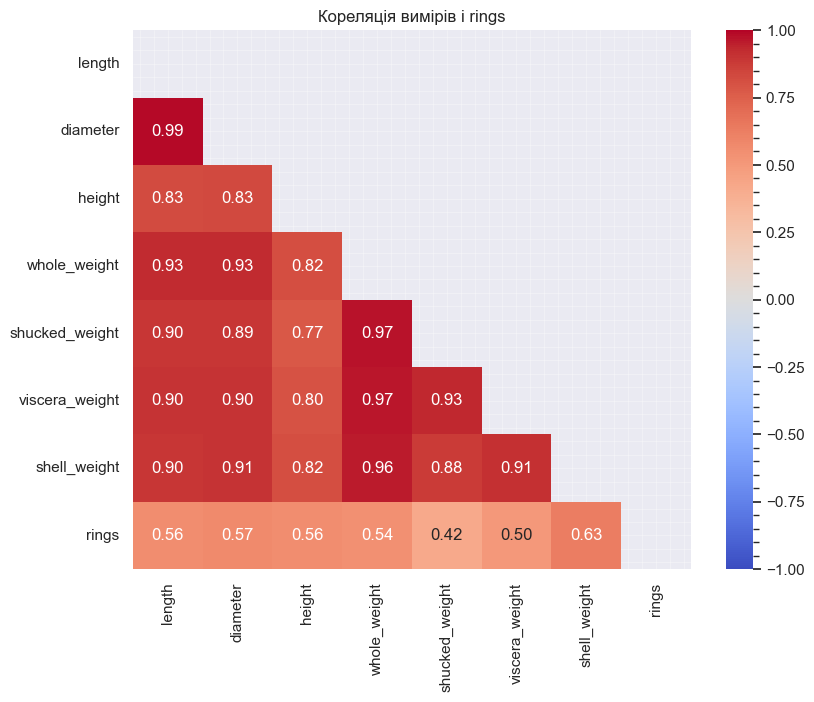

In [11]:
# Крок 2. Графічний аналіз
# Список числових вимірів (знадобиться далі)
measure_cols = ["length", "diameter", "height", "whole_weight",
                "shucked_weight", "viscera_weight", "shell_weight"]

# Кореляція вимірів між собою та з таргетом rings
plt.figure(figsize=(9, 7))
corr = df[measure_cols + ["rings"]].corr()
mask = np.triu(corr)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1, mask=mask)
plt.title("Кореляція вимірів і rings")
plt.show()

In [12]:
# З віком (rings) найсильніше пов'язана shell_weight (0.63) - тобто важча черепашка йде разом із більшою кількістю кілець; решта вимірів теж помітно корелюють (0.4-0.6). Але головне: усі виміри дуже сильно корелюють між собою (0.9+) - схоже, всі вони по суті міряють "розмір" мушлі. Для kNN це важливо: відстань між особинами майже повністю визначатиметься розміром.

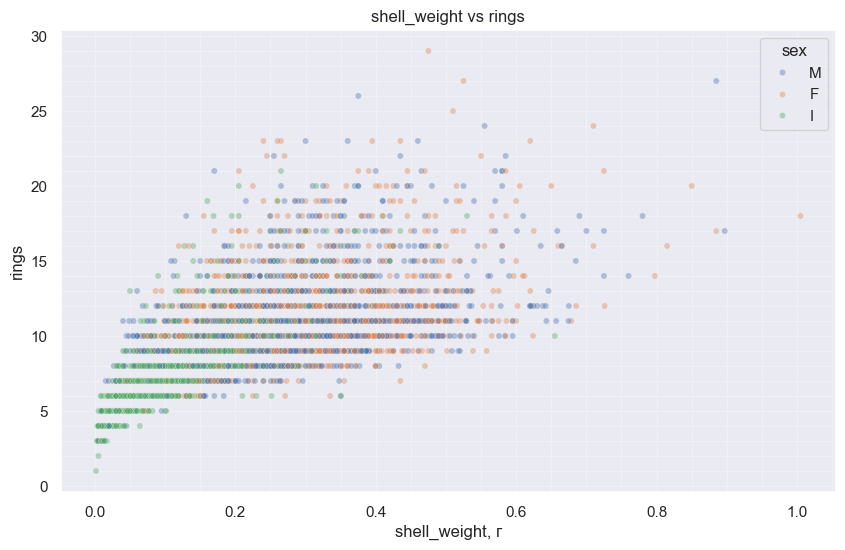

In [13]:
# Як найсильніший вимір (shell_weight) пов'язаний з віком, з розбивкою за статтю
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x="shell_weight", y="rings", hue="sex", alpha=0.4, s=20)
plt.title("shell_weight vs rings")
plt.xlabel("shell_weight, г")
plt.ylabel("rings")
plt.show()

In [14]:
# Видно чіткий зв'язок: важча черепашка - більше кілець. Але розкид великий, особливо в старих особин (при однаковій вазі кількість кілець може відрізнятись на кілька) - тому вгадати вік лише за розмірами ідеально не вийде. Молодь (infant) тулиться до низу-ліворуч: вона мала й молода.

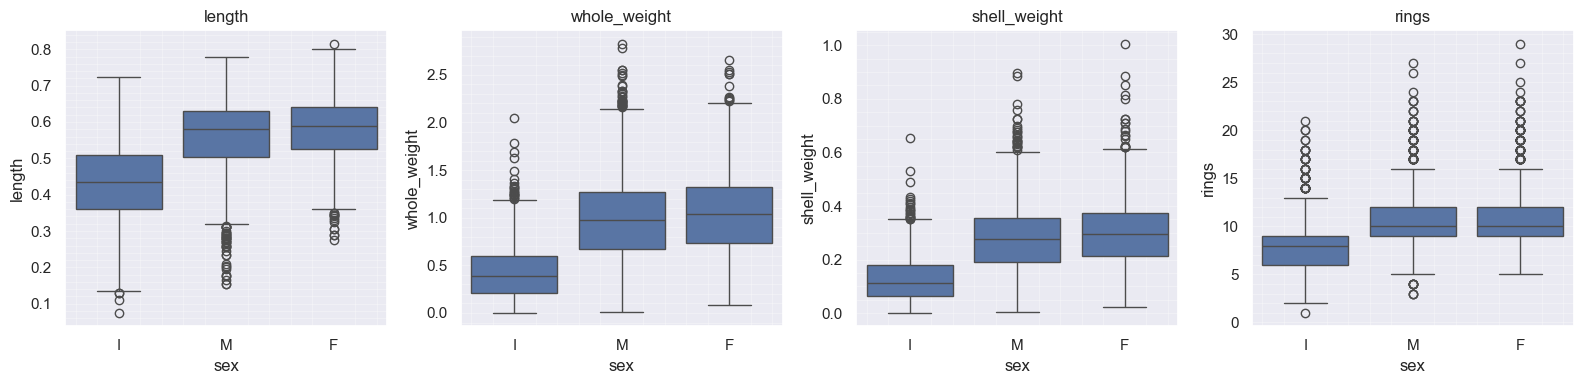

In [15]:
# Виміри в розрізі статі (M / F / I)
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, ["length", "whole_weight", "shell_weight", "rings"]):
    sns.boxplot(data=df, x="sex", y=col, order=["I", "M", "F"], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [16]:
# Тут видно ключове для додаткової задачі (класифікація статі): infant (I) помітно менші й молодші за дорослих - їх легко відрізнити. А от самці (M) і самки (F) за розмірами майже однакові (коробки майже збігаються) - розрізнити M і F буде важко. Тож наперед очікуємо: класифікатор добре ловитиме I, але плутатиме M і F.

In [17]:
# Крок 3. Фіча-інжиніринг
# Усі сирі виміри по суті описують "розмір" (сильно корелюють між собою). Тому додаємо
# дві фічі-пропорції, незалежні від розміру: частку м'яса і частку черепашки.
# Для kNN це нова вісь "складу мушлі", а не просто "яка вона велика".
df["shucked_ratio"] = df["shucked_weight"] / df["whole_weight"]  # частка м'яса
df["shell_ratio"] = df["shell_weight"] / df["whole_weight"]      # частка черепашки

df[["shucked_ratio", "shell_ratio", "rings"]].head()

,shucked_ratio,shell_ratio,rings
0,0.436770,0.291829,15
1,0.441242,0.310421,7
2,0.378877,0.310192,9
3,0.417636,0.300388,10
4,0.436585,0.268293,7


In [18]:
# Перевіряємо сигнал нових фіч (кореляція з rings)
df[["shucked_ratio", "shell_ratio"]].corrwith(df["rings"]).round(3)

shucked_ratio   -0.211
shell_ratio      0.120
dtype: float64

In [19]:
# Обидві нові фічі несуть сигнал: shucked_ratio (~-0.21) - більша частка м'яса йде разом із меншим віком, а shell_ratio (~+0.12) - більша частка черепашки трохи пов'язана з більшим віком. Головне: на відміну від сирих вимірів (усі про "розмір"), ці фічі описують склад мушлі незалежно від її розміру - тобто дають kNN нову, окрему інформацію для пошуку схожих особин.

In [20]:
# Крок 4. Препроцесинг (для основної задачі - регресії rings)
# Класифікацію sex зробимо окремим блоком пізніше - там ролі колонок інші.

# Числові фічі = 7 вимірів + 2 наші пропорції; sex - категоріальна (закодуємо)
numeric_features = measure_cols + ["shucked_ratio", "shell_ratio"]
X = df[numeric_features + ["sex"]]
y = df["rings"]

# Поділ train/val/test = 60/20/20
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=0.25, random_state=42)
print("train:", X_train.shape[0], "| val:", X_val.shape[0], "| test:", X_test.shape[0])

train: 2505 | val: 836 | test: 836


In [21]:
# Дані поділено 60/20/20. train - для навчання, val - для підбору кількості сусідів, test - фінальна чесна перевірка. Основний таргет - rings (вік); sex тут іде як звичайна вхідна фіча.

In [22]:
# Препроцесор: числові -> StandardScaler (масштабування), sex -> One-Hot
preprocessor = ColumnTransformer([
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(), ["sex"]),
])

# fit лише на train; val і test тільки трансформуємо
X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)

feat_names = preprocessor.get_feature_names_out()
X_train_prep = pd.DataFrame(X_train_prep, columns=feat_names, index=X_train.index)
X_val_prep = pd.DataFrame(X_val_prep, columns=feat_names, index=X_val.index)
X_test_prep = pd.DataFrame(X_test_prep, columns=feat_names, index=X_test.index)

print("колонок після препроцесингу:", X_train_prep.shape[1])
X_train_prep.head()

колонок після препроцесингу: 12


,num__length,num__diameter,num__height,num__whole_weight,num__shucked_weight,num__viscera_weight,num__shell_weight,num__shucked_ratio,num__shell_ratio,cat__sex_F,cat__sex_I,cat__sex_M
400,-0.342708,-0.450035,-0.507659,-0.497209,-0.410742,-0.459207,-0.467573,0.465974,0.018041,1.0,0.0,0.0
1371,0.755963,0.927380,0.801873,0.456108,0.564253,0.436284,0.394178,0.480948,-0.249820,0.0,0.0,1.0
3395,0.671449,0.417226,0.670919,0.801186,-0.015289,0.196255,1.040491,-2.359197,0.287161,1.0,0.0,0.0
2508,-0.934300,-0.960189,-0.900519,-1.026602,-0.999375,-1.017734,-1.042074,-0.093676,-0.127343,0.0,1.0,0.0
2704,1.474324,1.182457,0.932826,1.898883,2.336971,1.668737,1.650898,1.118278,-0.443098,0.0,0.0,1.0


In [23]:
# Масштабування - найважливіший крок для kNN. kNN міряє "відстань" між особинами, а виміри в різних одиницях (ваги в грамах ~1, розміри в мм ~0.5, частки 0..1). Без масштабування більші за числом фічі перетягли б відстань на себе, і "схожість" рахувалась би несправедливо. StandardScaler приводить усі фічі до середнього ~0 і розкиду ~1, тож кожна впливає порівну. Скейлер навчений лише на train (без витоку). sex розгорнуто в 3 колонки (sex_F, sex_I, sex_M). Разом: 9 числових + 3 = 12 колонок.

In [24]:
# Крок 5. Базова модель - KNeighborsRegressor з дефолтами (5 сусідів)
def evaluate(model, X, y, name):
    pred = model.predict(X)
    res = {"R2": r2_score(y, pred),
           "RMSE": mean_squared_error(y, pred) ** 0.5,
           "MAE": mean_absolute_error(y, pred)}
    print(f"{name:6} R2={res['R2']:.3f}  RMSE={res['RMSE']:.3f}  MAE={res['MAE']:.3f}")
    return res

knn = KNeighborsRegressor().fit(X_train_prep, y_train)
evaluate(knn, X_train_prep, y_train, "train")
baseline_val = evaluate(knn, X_val_prep, y_val, "val")

train  R2=0.679  RMSE=1.825  MAE=1.289
val    R2=0.478  RMSE=2.285  MAE=1.608


In [25]:
# Базова модель (5 сусідів за замовчуванням) на val дає R2 ~0.48 - пояснює приблизно половину розкиду віку, у середньому помиляється на ~1.6 кільця (MAE). На train помітно краще (R2 ~0.68), тобто є розрив: з 5 сусідами модель трохи перенавчається (мало сусідів = модель надто "чіпляється" за окремі найближчі точки). Далі підберемо кращу кількість сусідів, щоб зменшити цей розрив.

In [26]:
# Крок 6. Підбір гіперпараметрів kNN (GridSearchCV, 5-fold, метрика R2)
# n_neighbors - скільки сусідів; weights - усі порівну чи ближчі важливіші;
# p=1 - манхеттенська відстань, p=2 - звичайна евклідова
knn_params = {
    "n_neighbors": list(range(1, 41)),
    "weights": ["uniform", "distance"],
    "p": [1, 2],
}
knn_grid = GridSearchCV(KNeighborsRegressor(), knn_params, scoring="r2", cv=5, n_jobs=-1)
knn_grid.fit(X_train_prep, y_train)

best_knn = knn_grid.best_estimator_
print("найкращі параметри:", knn_grid.best_params_)
print("cv R2:", round(knn_grid.best_score_, 3))

найкращі параметри: {'n_neighbors': 35, 'p': 2, 'weights': 'distance'}
cv R2: 0.557


In [27]:
# Порівняння на val: базова модель vs налаштована
print("Базова (5 сусідів):")
evaluate(knn, X_val_prep, y_val, "val")
print("Налаштована:")
tuned_val = evaluate(best_knn, X_val_prep, y_val, "val")

Базова (5 сусідів):
val    R2=0.478  RMSE=2.285  MAE=1.608
Налаштована:
val    R2=0.549  RMSE=2.124  MAE=1.493


In [28]:
# Підбір покращив модель: найкраще - 35 сусідів (а не 5!), з вагою за відстанню (ближчі сусіди важать більше) і звичайною евклідовою відстанню. Більше сусідів = згладженіший, стабільніший прогноз: на val R2 зріс з 0.48 до 0.55, а помилка впала до ~1.5 кільця. Тобто 5 сусідів перенавчались, а 35 - кращий баланс. Але навіть так R2 ~0.55: за нашими даними при однаковій вазі кількість кілець помітно різниться (видно розкид на графіку Кроку 2), тож лише цих вимірів для точного віку не вистачає.

In [29]:
# Крок 7. Оцінка результатів - фінальна модель на train / val / test
final_summary = pd.DataFrame({
    "train": evaluate(best_knn, X_train_prep, y_train, "train"),
    "val":   evaluate(best_knn, X_val_prep, y_val, "val"),
    "test":  evaluate(best_knn, X_test_prep, y_test, "test"),
}).T.round(3)
final_summary

train  R2=1.000  RMSE=0.000  MAE=0.000
val    R2=0.549  RMSE=2.124  MAE=1.493
test   R2=0.572  RMSE=2.153  MAE=1.493


,R2,RMSE,MAE
train,1.000,0.000,0.000
val,0.549,2.124,1.493
test,0.572,2.153,1.493


In [30]:
# Головне - val і test майже однакові (R2 ~0.55 і ~0.57): на нових даних модель не просіла, тобто вона стабільна. У середньому помиляється на ~1.5 кільця. Не лякайся train R2=1.0: це не перенавчання, а особливість ваги "distance" - кожна навчальна точка сама собі найближчий сусід на нульовій відстані, тому на train завжди "ідеально". Судити треба саме за val/test.

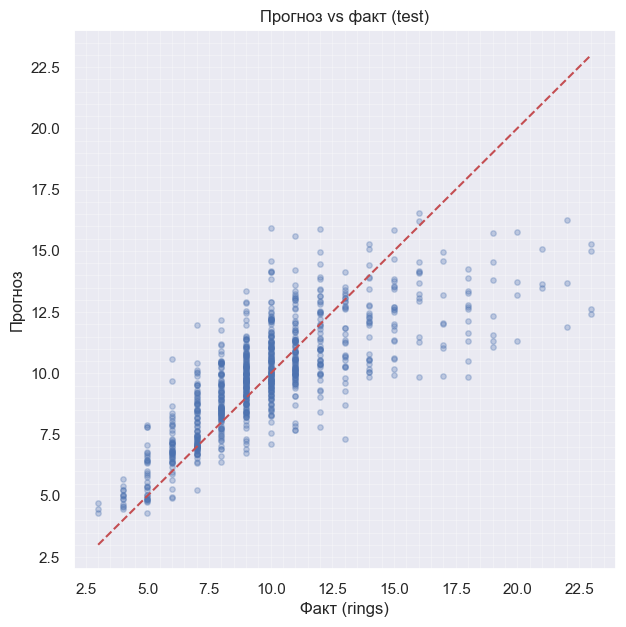

In [31]:
# Прогноз vs факт на test
pred_test = best_knn.predict(X_test_prep)
plt.figure(figsize=(7, 7))
plt.scatter(y_test, pred_test, alpha=0.3, s=15)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
plt.xlabel("Факт (rings)")
plt.ylabel("Прогноз")
plt.title("Прогноз vs факт (test)")
plt.show()

In [32]:
# Точки тягнуться вздовж червоної діагоналі - модель ловить загальну залежність. Але вона обережна: для дуже старих мушель (справа) прогноз майже завжди занижений, а для наймолодших - трохи завищений. Причина в самому усередненні: прогноз = середнє по 35 сусідах, а серед сусідів найстарішої мушлі трапляються молодші, тож середнє тягнеться до центру. Тому найстаріших особин модель недооцінює.

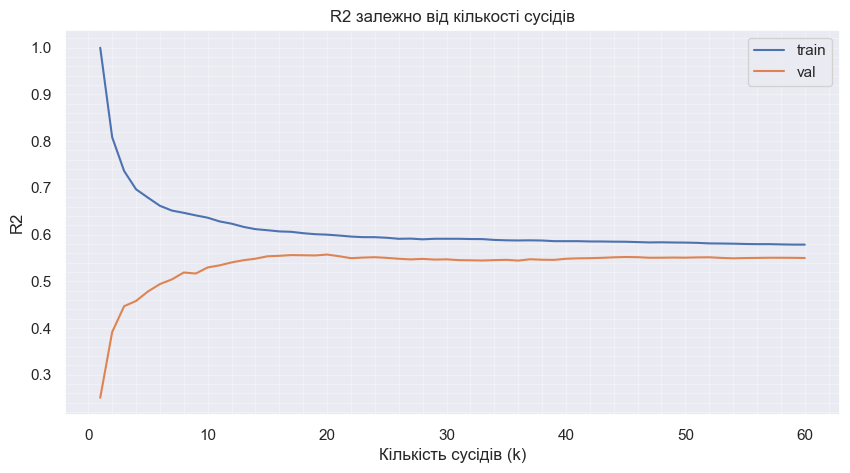

In [33]:
# Як кількість сусідів впливає на якість (крива для weights="uniform")
ks = range(1, 61)
train_scores, val_scores = [], []
for k in ks:
    m = KNeighborsRegressor(n_neighbors=k).fit(X_train_prep, y_train)
    train_scores.append(r2_score(y_train, m.predict(X_train_prep)))
    val_scores.append(r2_score(y_val, m.predict(X_val_prep)))

plt.figure(figsize=(10, 5))
plt.plot(ks, train_scores, label="train")
plt.plot(ks, val_scores, label="val")
plt.xlabel("Кількість сусідів (k)")
plt.ylabel("R2")
plt.title("R2 залежно від кількості сусідів")
plt.legend()
plt.show()

In [34]:
# На графіку видно: ліворуч (k=1-2) train майже ідеальний, а val низький - з малим k модель надто чіпляється за окремі точки. Зі зростанням k train падає, а val росте й виходить на "полицю" приблизно з k=15. Якщо брати ще більше сусідів, val помітно не зростає - прогноз стає надто усередненим. Тож найкраще - десь посередині, і GridSearchCV зупинився саме там.

In [35]:
# Крок 8. Додаткова задача - класифікація статі (sex) через KNeighborsClassifier
# Ролі колонок міняються: тепер sex - таргет, а rings стає звичайною числовою фічею.
clf_features = numeric_features + ["rings"]   # 9 числових + rings = 10 фіч
Xc = df[clf_features]
yc = df["sex"]

# Поділ 60/20/20 (у кожній частині - однакова частка кожної статі) + масштабування (знову критичне для kNN)
Xc_trainval, Xc_test, yc_trainval, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)
Xc_train, Xc_val, yc_train, yc_val = train_test_split(
    Xc_trainval, yc_trainval, test_size=0.25, random_state=42, stratify=yc_trainval)

scaler = StandardScaler()
Xc_train_s = scaler.fit_transform(Xc_train)
Xc_val_s = scaler.transform(Xc_val)
Xc_test_s = scaler.transform(Xc_test)
print("train:", Xc_train.shape[0], "| val:", Xc_val.shape[0], "| test:", Xc_test.shape[0])

train: 2505 | val: 836 | test: 836


In [36]:
# Базовий класифікатор і підбір параметрів (метрика f1_macro - однаково враховує всі 3 класи)
clf_base = KNeighborsClassifier().fit(Xc_train_s, yc_train)
print("baseline val: acc=%.3f  f1_macro=%.3f" % (
    accuracy_score(yc_val, clf_base.predict(Xc_val_s)),
    f1_score(yc_val, clf_base.predict(Xc_val_s), average="macro")))

clf_grid = GridSearchCV(
    KNeighborsClassifier(),
    {"n_neighbors": list(range(1, 41)), "weights": ["uniform", "distance"], "p": [1, 2]},
    scoring="f1_macro", cv=5, n_jobs=-1)
clf_grid.fit(Xc_train_s, yc_train)
best_clf = clf_grid.best_estimator_
print("найкращі параметри:", clf_grid.best_params_)

baseline val: acc=0.565  f1_macro=0.563


найкращі параметри: {'n_neighbors': 9, 'p': 1, 'weights': 'uniform'}


TEST: acc=0.557  f1_macro=0.557


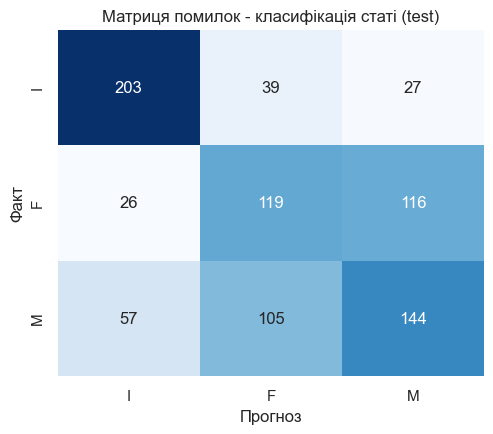

In [37]:
# Оцінка на test + матриця помилок
yc_pred = best_clf.predict(Xc_test_s)
print("TEST: acc=%.3f  f1_macro=%.3f" % (
    accuracy_score(yc_test, yc_pred), f1_score(yc_test, yc_pred, average="macro")))

cm = confusion_matrix(yc_test, yc_pred, labels=["I", "F", "M"])
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["I", "F", "M"], yticklabels=["I", "F", "M"])
plt.xlabel("Прогноз")
plt.ylabel("Факт")
plt.title("Матриця помилок - класифікація статі (test)")
plt.show()

In [38]:
# Точність ~0.56 - краще за випадкове вгадування (1/3), але невисоко. Матриця помилок показує чому, точно як ми очікували в Кроці 2: infant (I) модель ловить добре (~75% вгадано), а от самців (M) і самок (F) вона масово плутає між собою (майже половина M потрапляє у F і навпаки). Схоже, річ у самих даних: на графіках Кроку 2 виміри M і F майже збігаються, тож розрізнити їх за цими вимірами важко. Підбір параметрів тут майже не допоміг - схоже, проблема в самих даних, а не в налаштуваннях.

In [39]:
# Підсумок
# Ми зробили дві задачі методом найближчих сусідів (kNN) на даних про мушлі абалону.
#
# 1) Основна - передбачення віку (rings). Найкраще спрацювало 35 сусідів з вагою за
#    відстанню; на test R2 ~0.57, у середньому модель помиляється на ~1.5 кільця.
#    Точніше важко: за нашими даними мушлі схожого розміру часто мають різний вік,
#    тож самих вимірів для цього не вистачає.
#
# 2) Додаткова - визначення статі (sex). Точність ~0.56. Молодь (infant) модель
#    впізнає добре, а от самців і самок майже не розрізняє - за нашими даними їхні
#    виміри майже збігаються.
#
# Що варто запам'ятати про kNN:
# - масштабування фіч обов'язкове, бо модель рахує відстань між мушлями;
# - кількість сусідів k впливає на якість: мало - прогноз нестабільний, багато -
#   надто усереднений; зручний k ми підбирали через GridSearchCV;
# - нові фічі-пропорції (частка м'яса / черепашки) додали моделі "склад" мушлі,
#   а не лише "розмір".